### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

### Importing Data

In [2]:
#import data
df = pd.read_csv("/Users/aurko/Desktop/Data Science Projects/Rental Prices of AirBnb/data.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


### Data Preprocessing

In [3]:
# drop columns that are not required
df = df.drop(['id', 'name', 'host_id', 'host_name', 'last_review', 'number_of_reviews', 'reviews_per_month', 'neighbourhood'], axis=1)
df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0
1,Brooklyn,40.68769,-73.97490,Private room,99,5,1,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,1,74
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,2,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,1,20


In [4]:
# check for missing values
df.isnull().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [5]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# total number of rows and columns
df.shape

(27379, 8)

### Checking for Outliers

In [7]:
# function to check for outliers
def check_outliers(df,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [8]:
# check for outliers
check_outliers(df, 'price')

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
17,Manhattan,40.75403,-73.96714,Entire home/apt,714,28,49,250
35,Manhattan,40.73722,-74.00263,Entire home/apt,1500,3,1,54
42,Manhattan,40.74478,-73.98442,Entire home/apt,349,4,1,255
56,Manhattan,40.76515,-73.98586,Entire home/apt,389,1,1,0
75,Manhattan,40.75000,-73.99637,Entire home/apt,395,3,1,0
...,...,...,...,...,...,...,...,...
27286,Manhattan,40.76955,-73.95988,Entire home/apt,589,6,1,4
27326,Brooklyn,40.65716,-73.97550,Entire home/apt,450,4,2,87
27331,Manhattan,40.71895,-73.99793,Entire home/apt,5250,1,1,0
27355,Manhattan,40.74775,-73.99167,Entire home/apt,999,2,1,0


### Result of Outliers

As the data contains outliers it would effect the model drastically. Since Outliers are data that are significantly different from rest of the data, and they can skew the results of the analysis. Therefore the accuracy of the model would be affected.

In [9]:
print(df['room_type'].unique())

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str


### Label Encoding for converting textual data into numerical data

In [10]:
# encode categorical variables using label encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['neighbourhood_group'] = le.fit_transform(df['neighbourhood_group'])
df['room_type'] = le.fit_transform(df['room_type'])

df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
0,1,40.69591,-73.96284,1,58,2,1,0
1,1,40.68769,-73.97490,1,99,5,1,250
2,1,40.67667,-73.91750,0,180,2,1,74
3,3,40.74340,-73.90588,0,50,1,2,0
4,1,40.66600,-73.99020,0,210,4,1,20


### Splitting Data Into Train and Test set

In [11]:
# split data into three sets: Train, Test and Split
from sklearn.model_selection import train_test_split

x = df.drop('price', axis=1)
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_safe, y_train, y_safe = train_test_split(x, y, test_size=0.2, random_state=42)

### Scaling the Data

In [12]:
#scale data
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### Applying Model of the Data 

In [14]:
# train model 
from sklearn.linear_model import LogisticRegression

regressor = LogisticRegression()
regressor.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Prediction on Trained Model

In [15]:
# predict
y_pred = regressor.predict(x_test)
y_pred

array([150,  50, 100, ..., 150, 175, 200], shape=(5476,))

### Accuracy of the Model

In [16]:
# evaluate model
from sklearn.metrics import r2_score

print('R2 Score: ', r2_score(y_test, y_pred))

R2 Score:  0.09454487695927605


In [18]:
# print accuracy score of the model
print('Accuracy of linear regression classifier on the test set: {:.2f}'.format(100*(regressor.score(x_test, y_test))))

Accuracy of linear regression classifier on the test set: 7.65


### Visualization

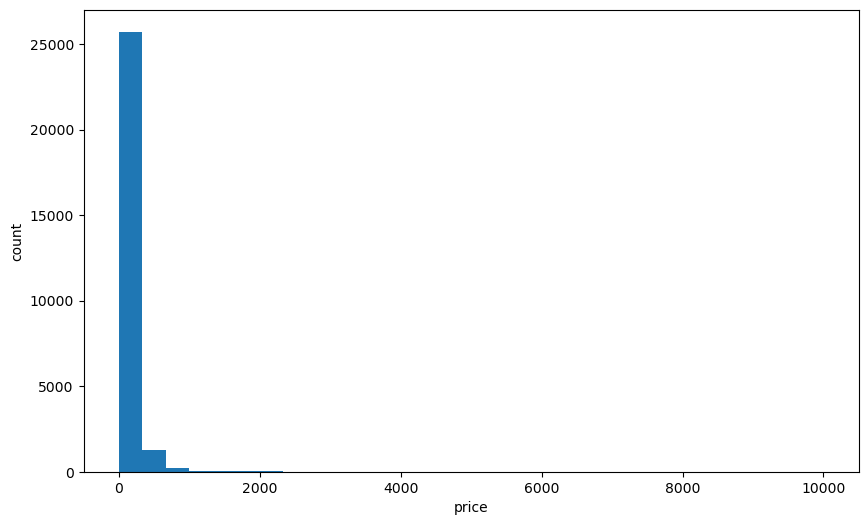

In [19]:
# exploratory data analysis
import matplotlib.pyplot as plt

# plot the distribution of price
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=30)
plt.xlabel('price')
plt.ylabel('count')
plt.show()

<Axes: xlabel='minimum_nights', ylabel='price'>

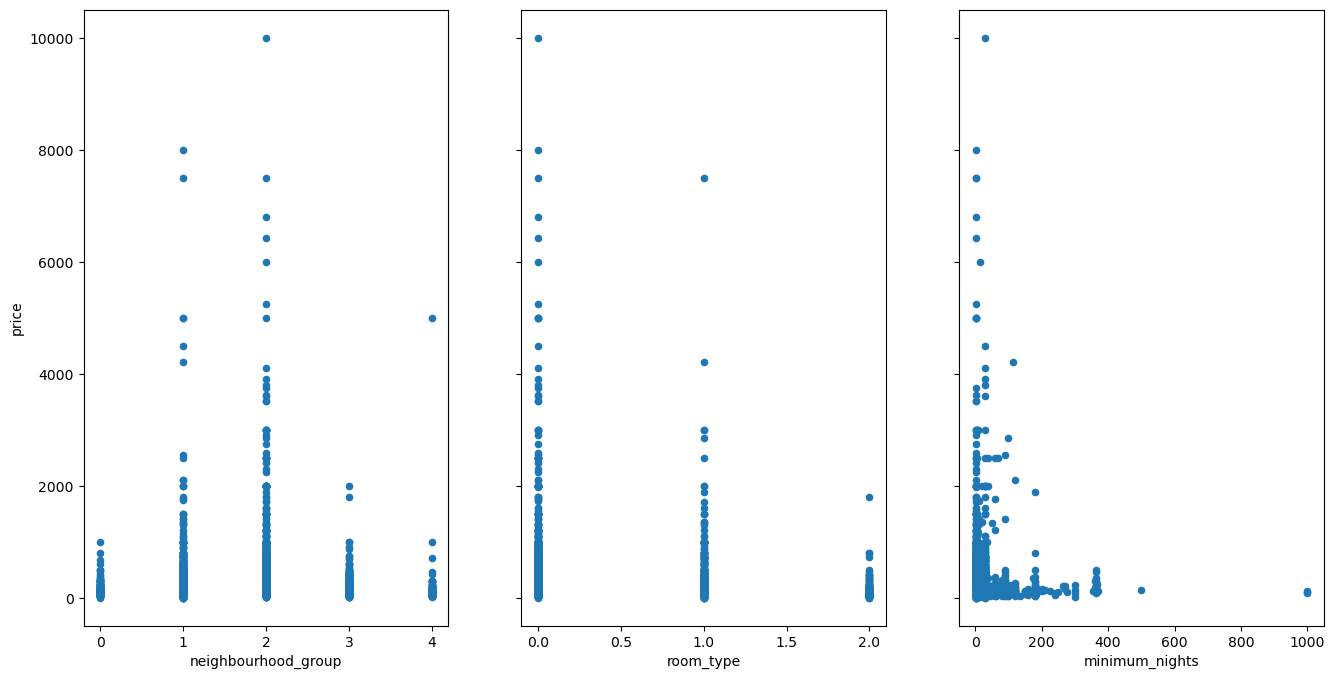

In [22]:
# visualize the relationship between the features and the response using scatterplots
fig, axs = plt.subplots(1, 3, sharey=True)
df.plot(kind='scatter', x='neighbourhood_group', y='price', ax=axs[0], figsize=(16, 8))
df.plot(kind='scatter', x='room_type', y='price', ax=axs[1])
df.plot(kind='scatter', x='minimum_nights', y='price', ax=axs[2])

### Summary Statistics

In [24]:
# summary statistic
df.describe()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
count,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000
mean,1.675993,40.728836,-73.952071,0.502721,151.569561,7.056722,7.228788,113.430293
std,0.735011,0.054629,0.046278,0.544685,219.807784,20.194945,33.173634,132.039807
min,0.000000,40.506410,-74.242850,0.000000,0.000000,1.000000,1.000000,0.000000
25%,1.000000,40.689955,-73.983080,0.000000,69.000000,1.000000,1.000000,0.000000
50%,2.000000,40.723030,-73.955700,0.000000,105.000000,3.000000,1.000000,45.000000
75%,2.000000,40.763045,-73.935830,1.000000,175.000000,5.000000,2.000000,230.000000
max,4.000000,40.913060,-73.717950,2.000000,10000.000000,999.000000,327.000000,365.000000
